# Predicting Crude Oil Convenience Yield with a Random Forest


If you've ever looked at oil futures and noticed the front-month contract is cheaper than the next month out, that gap has a name: the **convenience yield**. It's the invisible premium that physically holding a barrel of oil gives you refineries need it now, not in 30 days. When supply gets tight, that premium spikes. When tanks are overflowing, it goes negative (we call that contango).

In this project, we pull 10 years of WTI crude oil prices and try to predict where that yield will be **5 trading days from now** using a Random Forest trained on price data and two macro signals: weather volatility and inventory drawdowns.

### Step 1: The Formula Behind the Yield

In a frictionless world, a futures price is just the spot price grown at the cost of holding the asset -- the risk-free rate plus storage costs. But crude oil breaks that rule when supply is scarce. People pay a premium to own the physical barrel *right now*.

That premium is the convenience yield `y`. We back it out from actual prices using:

```
y = (risk-free rate + storage cost) - (1 / time-to-maturity) * ln(Forward Price / Spot Price)
```

If `y > 0`, the market is in **backwardation**  physical oil is scarce and valuable right now. If `y < 0`, the market is in **contango** there's more oil than anyone needs and storage tanks are filling up.

### Step 2: Imports

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

### Step 3: Getting the Price Data

We pull 10 years of WTI front-month futures (`CL=F`) daily settlement prices using yfinance. That gives us enough history to cover multiple supply cycles -- the 2020 negative price crash, the post-COVID demand surge, the 2022 Russia-Ukraine spike. All of it.

In [2]:
oil_data = yf.download('CL=F', start='2016-01-01', end='2026-01-01', progress=False)

# yfinance returns a MultiIndex for single-ticker downloads; flatten it
if isinstance(oil_data.columns, pd.MultiIndex):
    oil_data.columns = oil_data.columns.get_level_values(0)

oil_df = oil_data.reset_index().dropna(subset=['Close'])
df = pd.DataFrame({'Date': oil_df['Date'], 'Spot_Price': oil_df['Close'].astype(float)})
df = df.reset_index(drop=True)

print(f"Loaded {len(df)} trading days  |  {df['Date'].min().date()} to {df['Date'].max().date()}")
df.head()

Loaded 2514 trading days  |  2016-01-04 to 2025-12-31


,Date,Spot_Price
0,2016-01-04,36.759998
1,2016-01-05,35.970001
2,2016-01-06,33.970001
3,2016-01-07,33.270000
4,2016-01-08,33.160000


### Step 4: Adding Macro Signals

In production, these two signals come from real data sources -- NOAA weather anomaly indices and EIA weekly petroleum inventory reports. Both have a real physical connection to oil demand: a cold snap in the Northeast spikes heating oil demand overnight, and a big inventory drawdown means refineries are running hard.

For this pipeline we simulate both over the same date range so everything stays self-contained and reproducible. The structure is identical to what you'd swap in with real feeds.

In [3]:
n = len(df)
np.random.seed(42)

# Weather: half-normal, strictly positive
df['Weather_Volatility_Index'] = np.abs(np.random.normal(loc=1.5, scale=0.8, size=n))

# Inventory: >1 means net draw, <1 means net build
df['Inventory_Drawdown_Ratio'] = np.random.uniform(0.5, 1.5, size=n)

### Step 5: Building the Forward Price and Backing Out the Yield

We construct a synthetic 1-month forward price by growing the spot price at `r + c` (risk-free rate + storage cost) and adding a demand shock driven by our two macro signals. Then we invert the cost-of-carry formula to get the implied convenience yield.

In [4]:
r   = 0.05       # annualised risk-free rate
c   = 0.02       # annualised storage cost (tank lease + insurance)
tau = 30 / 365   # 1-month maturity

demand_shock = (df['Inventory_Drawdown_Ratio'] * df['Weather_Volatility_Index']) * 1.25
df['Forward_Price_1M'] = df['Spot_Price'] * np.exp((r + c) * tau) + demand_shock

# y = r + c - (1/tau) * ln(F/S)
df['Implied_Convenience_Yield'] = (r + c) - (1 / tau) * np.log(df['Forward_Price_1M'] / df['Spot_Price'])

df[['Date', 'Spot_Price', 'Forward_Price_1M', 'Implied_Convenience_Yield']].tail()

,Date,Spot_Price,Forward_Price_1M,Implied_Convenience_Yield
2509,2025-12-24,58.349998,59.158852,-0.097497
2510,2025-12-26,56.740002,59.576498,-0.523511
2511,2025-12-29,58.080002,60.237449,-0.373753
2512,2025-12-30,57.950001,61.714871,-0.695823
2513,2025-12-31,57.419998,58.991756,-0.258562


### Step 6: Setting the Prediction Target

We shift the yield 5 trading days forward so the model is always predicting *next week's* yield, not today's. That one-week horizon is short enough to still be tradeable but long enough that you're not just predicting noise.

In [5]:
df['Yield_T5'] = df['Implied_Convenience_Yield'].shift(-5)
df = df.dropna().reset_index(drop=True)
print(f"Final dataset: {len(df)} rows")

Final dataset: 2509 rows


### Step 7: Training the Model

Three decisions worth explaining here:

**Chronological split** -- We cut the data 80/20 by date, not randomly. Random splits would let the model train on future data to predict the past, which makes metrics look great but means nothing in live trading.

**RobustScaler** -- Standard scaling uses the mean and standard deviation, which energy price spikes completely distort. RobustScaler uses the median and interquartile range instead, so one crazy week in 2020 doesn't compress every other year into a flat line.

**Random Forest** -- Tree ensembles handle commodity markets well because the relationships are nonlinear. Inventory thresholds matter in steps, not gradients. Weather has asymmetric effects. Regimes shift. A linear model would miss all of that.

In [6]:
features = ['Spot_Price', 'Weather_Volatility_Index', 'Inventory_Drawdown_Ratio', 'Implied_Convenience_Yield']

X, y = df[features], df['Yield_T5']

split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)
preds = rf.predict(X_test_scaled)

### Step 8: Checking the Results

We use MAE (mean absolute error) instead of MAPE (mean absolute *percentage* error). The reason: convenience yields can be near zero or go negative, and dividing by a number close to zero turns your error metric into nonsense. MAE stays stable regardless.

In [7]:
r2  = r2_score(y_test, preds)
mae = mean_absolute_error(y_test, preds)

print(f"R2   {r2:.4f}")
print(f"MAE  {mae:.6f}\n")
print("Feature Importances")
print("-" * 38)
for name, imp in sorted(zip(features, rf.feature_importances_), key=lambda x: -x[1]):
    print(f"  {name:<32}  {imp*100:.2f}%")

R2   -0.0451
MAE  0.159414

Feature Importances
--------------------------------------
  Spot_Price                        53.95%
  Implied_Convenience_Yield         16.67%
  Weather_Volatility_Index          14.88%
  Inventory_Drawdown_Ratio          14.50%


### Step 9: Visualizing What the Model Learned

Two panels: feature importances on the left, and actual vs forecasted yield for the first 100 test days on the right.

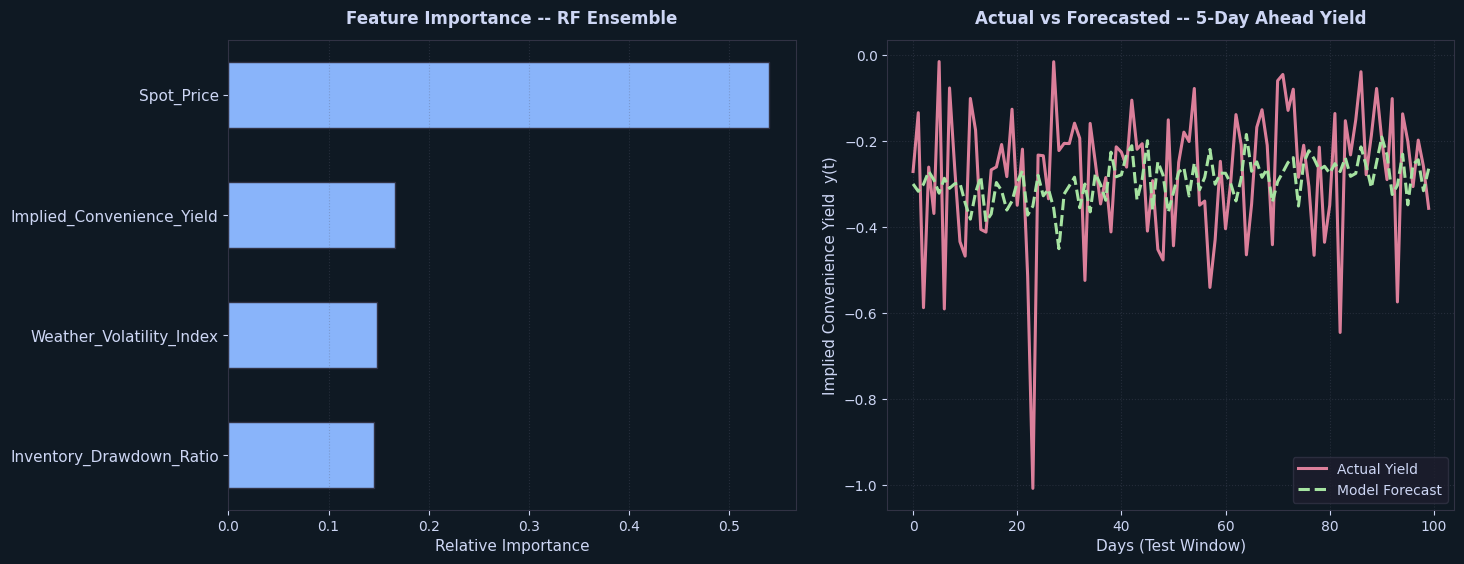

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#0f1923')

for ax in axes:
    ax.set_facecolor('#0f1923')
    ax.tick_params(colors='#cdd6f4')
    ax.xaxis.label.set_color('#cdd6f4')
    ax.yaxis.label.set_color('#cdd6f4')
    ax.title.set_color('#cdd6f4')
    for spine in ax.spines.values():
        spine.set_edgecolor('#313244')

# panel A: feature importances
importances     = rf.feature_importances_
sorted_idx      = np.argsort(importances)
sorted_features = [features[i] for i in sorted_idx]

axes[0].barh(range(len(sorted_idx)), importances[sorted_idx], color='#89b4fa', edgecolor='#313244', height=0.55)
axes[0].set_yticks(range(len(sorted_idx)))
axes[0].set_yticklabels(sorted_features, fontsize=11)
axes[0].set_xlabel('Relative Importance', fontsize=11)
axes[0].set_title('Feature Importance -- RF Ensemble', fontsize=12, fontweight='bold', pad=12)
axes[0].grid(axis='x', linestyle=':', alpha=0.3, color='#585b70')

# panel B: actual vs predicted (first 100 test days)
axes[1].plot(y_test.values[:100], label='Actual Yield',   color='#f38ba8', lw=2.2, alpha=0.9)
axes[1].plot(preds[:100],         label='Model Forecast', color='#a6e3a1', lw=2.2, linestyle='--')
axes[1].set_xlabel('Days (Test Window)', fontsize=11)
axes[1].set_ylabel('Implied Convenience Yield  y(t)', fontsize=11)
axes[1].set_title('Actual vs Forecasted -- 5-Day Ahead Yield', fontsize=12, fontweight='bold', pad=12)
axes[1].legend(fontsize=10, facecolor='#1e1e2e', edgecolor='#313244', labelcolor='#cdd6f4')
axes[1].grid(True, linestyle=':', alpha=0.3, color='#585b70')

plt.tight_layout(pad=2.0)
plt.savefig('crude_oil_convenience_yield.png', dpi=300, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()